<a href="https://colab.research.google.com/github/Mayruok/Chicago-crime-arrest-prediction/blob/main/Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install pyspark

from google.colab import drive
drive.mount('/content/drive')

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ChicagoCrimeArrest") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()


Mounted at /content/drive


In [6]:
from pyspark.sql.functions import col, to_timestamp, year

raw_path = "/content/Crimes_-_2001_to_Present.csv" # Updated path
bronze_path = "/content/drive/MyDrive/chicago/bronze"

# Read raw CSV into Bronze
df_bronze = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv(raw_path)

print("Bronze row count:", df_bronze.count())
df_bronze.printSchema()
df_bronze.show(5, truncate=False)

# Add proper timestamp + Year column
df_bronze = df_bronze.withColumn(
    "Date_ts",
    to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a")
)
df_bronze = df_bronze.withColumn("Year", year(col("Date_ts")))

# Write as partitioned Parquet (Bronze)
df_bronze.write \
    .mode("overwrite") \
    .partitionBy("Year") \
    .parquet(bronze_path)

Bronze row count: 382940
root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)

+--------+-----------+----------------------+-----------------------+--

In [7]:
from pyspark.sql.functions import isnan, when, count, col
from pyspark.sql.types import DoubleType, FloatType

bronze_path = "/content/drive/MyDrive/chicago/bronze"
silver_path = "/content/drive/MyDrive/chicago/silver"

df_bronze = spark.read.parquet(bronze_path)

# Missing values per column (quick overview)
missing_expressions = []
for c in df_bronze.columns:
    if isinstance(df_bronze.schema[c].dataType, (DoubleType, FloatType)):
        missing_expressions.append(count(when(col(c).isNull() | isnan(c), c)).alias(c))
    else:
        missing_expressions.append(count(when(col(c).isNull(), c)).alias(c))

missing = df_bronze.select(missing_expressions)
missing.show(truncate=False)

# Filter out null target and broken timestamps
df_silver = df_bronze.filter(col("Arrest").isNotNull())
df_silver = df_silver.filter(col("Date_ts").isNotNull())
df_silver = df_silver.filter(col("Year") >= 2001)

# Optional: require valid coordinates for spatial features
df_silver = df_silver.filter(
    col("Latitude").isNotNull() & col("Longitude").isNotNull()
)

# Drop duplicate incident IDs
df_silver = df_silver.dropDuplicates(["ID"])

print("Silver row count:", df_silver.count())

df_silver.write.mode("overwrite").parquet(silver_path)

+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+------+--------------+--------+------------+------------+----------+--------+---------+--------+-------+----+
|ID |Case Number|Date|Block|IUCR|Primary Type|Description|Location Description|Arrest|Domestic|Beat|District|Ward  |Community Area|FBI Code|X Coordinate|Y Coordinate|Updated On|Latitude|Longitude|Location|Date_ts|Year|
+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+------+--------------+--------+------------+------------+----------+--------+---------+--------+-------+----+
|0  |0          |0   |0    |0   |0           |0          |1527                |0     |0       |0   |0       |267684|266537        |0       |10645       |10645       |0         |10645   |10645    |10645   |0      |0   |
+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+------+--------

In [8]:
from pyspark.sql.functions import col

silver_path = "/content/drive/MyDrive/chicago/silver"
df_silver = spark.read.parquet(silver_path)

print("Row count:", df_silver.count())
df_silver.printSchema()

# Target distribution
df_silver.groupBy("Arrest").count().show()

# Crime type distribution
df_silver.groupBy("Primary Type").count() \
    .orderBy(col("count").desc()) \
    .show(20, truncate=False)

# Numeric stats
df_silver.describe(["Latitude", "Longitude", "Year"]).show()

Row count: 372295
root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- Date_ts: timestamp (nullable = true)
 |-- Year: integer (nullable = true)

+------+------+
|Arrest| count|
+---

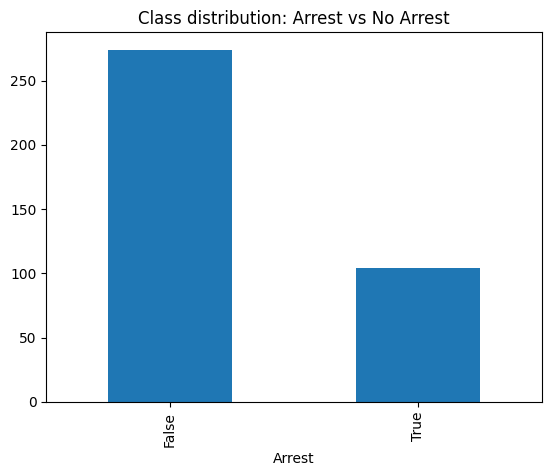

In [9]:
sample_pd = df_silver.sample(False, 0.001, seed=42).toPandas()

import matplotlib.pyplot as plt

sample_pd["Arrest"].value_counts().plot(kind="bar")
plt.title("Class distribution: Arrest vs No Arrest")
plt.show()

In [10]:
from pyspark.sql.functions import hour, dayofweek, month, when

gold_path = "/content/drive/MyDrive/chicago/gold_mlready"

df_gold = df_silver.withColumn("Hour", hour(col("Date_ts"))) \
    .withColumn("DayOfWeek", dayofweek(col("Date_ts"))) \
    .withColumn("Month", month(col("Date_ts"))) \
    .withColumn("IsWeekend", when(col("DayOfWeek").isin(1,7), 1).otherwise(0)) \
    .withColumn("label", when(col("Arrest") == True, 1).otherwise(0))

df_gold.write.mode("overwrite").parquet(gold_path)

In [11]:
from pyspark.sql.functions import count, sum as spark_sum

gold_path = "/content/drive/MyDrive/chicago/gold_mlready"
agg_path = "/content/drive/MyDrive/chicago/agg_for_tableau"

df_gold = spark.read.parquet(gold_path)

# Arrest rate by Year and Primary Type
agg_year_type = df_gold.groupBy("Year", "Primary Type") \
    .agg(
        count("*").alias("TotalCrimes"),
        (spark_sum(col("label")) / count("*")).alias("ArrestRate")
    )

agg_year_type.write.mode("overwrite").parquet(agg_path + "/year_primarytype")

# Arrest rate by District
agg_district = df_gold.groupBy("District") \
    .agg(
        count("*").alias("TotalCrimes"),
        (spark_sum(col("label")) / count("*")).alias("ArrestRate")
    )

agg_district.write.mode("overwrite").parquet(agg_path + "/district")

In [12]:
agg_year_type.write.mode("overwrite").option("header", True) \
    .csv("/content/drive/MyDrive/chicago/tableau/year_primarytype_csv")

agg_district.write.mode("overwrite").option("header", True) \
    .csv("/content/drive/MyDrive/chicago/tableau/district_csv")

In [13]:
gold_path = "/content/drive/MyDrive/chicago/gold_mlready"
df_gold = spark.read.parquet(gold_path)

train_df, test_df = df_gold.randomSplit([0.8, 0.2], seed=42)

print("Train distribution:")
train_df.groupBy("label").count().show()

print("Test distribution:")
test_df.groupBy("label").count().show()

Train distribution:
+-----+------+
|label| count|
+-----+------+
|    1| 78602|
|    0|219185|
+-----+------+

Test distribution:
+-----+-----+
|label|count|
+-----+-----+
|    1|19657|
|    0|54851|
+-----+-----+



In [14]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

categorical_cols = [
    "Primary Type", "Location Description",
    "District", "Ward", "Community Area", "FBI Code"
]

numeric_cols = ["Latitude", "Longitude", "Hour", "DayOfWeek", "Month", "IsWeekend", "Domestic"]

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in categorical_cols],
    outputCols=[c + "_ohe" for c in categorical_cols]
)

assembler = VectorAssembler(
    inputCols=[c + "_ohe" for c in categorical_cols] + numeric_cols,
    outputCol="features_unnormalized"
)

scaler = StandardScaler(
    inputCol="features_unnormalized",
    outputCol="features",
    withMean=False,
    withStd=True
)

In [15]:
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier
)
from pyspark.ml import Pipeline

lr = LogisticRegression(featuresCol="features", labelCol="label")
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)
gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=50)

base_stages = indexers + [encoder, assembler, scaler]

pipelines = {
    "LogisticRegression": Pipeline(stages=base_stages + [lr]),
    "DecisionTree": Pipeline(stages=base_stages + [dt]),
    "RandomForest": Pipeline(stages=base_stages + [rf]),
    "GBT": Pipeline(stages=base_stages + [gbt]),
}

In [16]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col

binary_eval = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

acc_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall"
)

results = {}
predictions_path = "/content/drive/MyDrive/chicago/predictions"

for name, pipe in pipelines.items():
    print("="*40, name, "="*40)

    # Explicitly cast 'Domestic' to IntegerType for train_df and test_df
    # This addresses the IllegalArgumentException where VectorAssembler expects numeric type, not BooleanType
    train_df_prepared = train_df.withColumn("Domestic", col("Domestic").cast("int"))
    test_df_prepared = test_df.withColumn("Domestic", col("Domestic").cast("int"))

    model = pipe.fit(train_df_prepared)
    preds = model.transform(test_df_prepared)
    preds.cache()

    acc = acc_eval.evaluate(preds)
    f1 = f1_eval.evaluate(preds)
    prec = precision_eval.evaluate(preds)
    rec = recall_eval.evaluate(preds)
    auc = binary_eval.evaluate(preds)

    print(f"{name} -> Accuracy: {acc:.4f}, F1: {f1:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, AUC: {auc:.4f}")
    preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

    # Save predictions for Tableau
    preds.select("Year", "Primary Type", "District", "label", "prediction", "probability") \
         .write.mode("overwrite").parquet(f"{predictions_path}/{name}")

    results[name] = (model, preds)

======================================== LogisticRegression ========================================
LogisticRegression -> Accuracy: 0.8582, F1: 0.8470, Precision: 0.8585, Recall: 0.8582, AUC: 0.8689
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|53092|
|    0|       1.0| 1759|
|    1|       0.0| 8804|
|    1|       1.0|10853|
+-----+----------+-----+

======================================== DecisionTree ========================================
DecisionTree -> Accuracy: 0.8418, F1: 0.8189, Precision: 0.8588, Recall: 0.8418, AUC: 0.2911
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|54365|
|    0|       1.0|  486|
|    1|       0.0|11300|
|    1|       1.0| 8357|
+-----+----------+-----+

======================================== RandomForest ========================================
RandomForest -> Accuracy: 0.8242, F1: 0.7898, Precision: 0.8574, Recall: 0.8242, AUC: 0.8504
+-----+----------+----

In [17]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.functions import col

rf_pipe = pipelines["RandomForest"]

paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

rf_cv = CrossValidator(
    estimator=rf_pipe,
    estimatorParamMaps=paramGrid,
    evaluator=binary_eval,
    numFolds=3,
    parallelism=2
)

# Explicitly cast 'Domestic' to IntegerType for train_df and test_df
# This addresses the IllegalArgumentException where VectorAssembler expects numeric type, not BooleanType
train_df_prepared = train_df.withColumn("Domestic", col("Domestic").cast("int"))
test_df_prepared = test_df.withColumn("Domestic", col("Domestic").cast("int"))

rf_cv_model = rf_cv.fit(train_df_prepared)
rf_cv_preds = rf_cv_model.transform(test_df_prepared)

acc = acc_eval.evaluate(rf_cv_preds)
f1 = f1_eval.evaluate(rf_cv_preds)
auc = binary_eval.evaluate(rf_cv_preds)

print(f"RF (CV) -> Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

RF (CV) -> Accuracy: 0.8369, F1: 0.8091, AUC: 0.8623


In [18]:
# Get best RF model (if using CV)
rf_best_pipeline = rf_cv_model.bestModel
rf_best_model = rf_best_pipeline.stages[-1]   # RandomForestClassifier

importances = rf_best_model.featureImportances
print("Number of features:", importances.size)
print(importances)

Number of features: 426
(426,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,26,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,127,128,129,130,131,133,135,136,137,139,146,148,151,153,157,158,159,161,164,175,194,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,

In [19]:
for name, (model, preds) in results.items():
    print("Confusion matrix for", name)
    preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

Confusion matrix for LogisticRegression
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|53092|
|    0|       1.0| 1759|
|    1|       0.0| 8804|
|    1|       1.0|10853|
+-----+----------+-----+

Confusion matrix for DecisionTree
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|54365|
|    0|       1.0|  486|
|    1|       0.0|11300|
|    1|       1.0| 8357|
+-----+----------+-----+

Confusion matrix for RandomForest
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|54832|
|    0|       1.0|   19|
|    1|       0.0|13082|
|    1|       1.0| 6575|
+-----+----------+-----+

Confusion matrix for GBT
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|53880|
|    0|       1.0|  971|
|    1|       0.0| 9194|
|    1|       1.0|10463|
+-----+----------+-----+



In [20]:
for name, (model, preds) in results.items():
    preds.groupBy("label", "prediction").count() \
        .write.mode("overwrite").option("header", True) \
        .csv(f"/content/drive/MyDrive/chicago/tableau/confusion_{name}")

In [21]:
import time

print("Gold partitions:", df_gold.rdd.getNumPartitions())

start = time.time()
# Use train_df_prepared where 'Domestic' column is cast to int
_ = pipelines["RandomForest"].fit(train_df_prepared)
print("RF training time (no CV):", time.time() - start, "seconds")

Gold partitions: 2
RF training time (no CV): 75.62448978424072 seconds


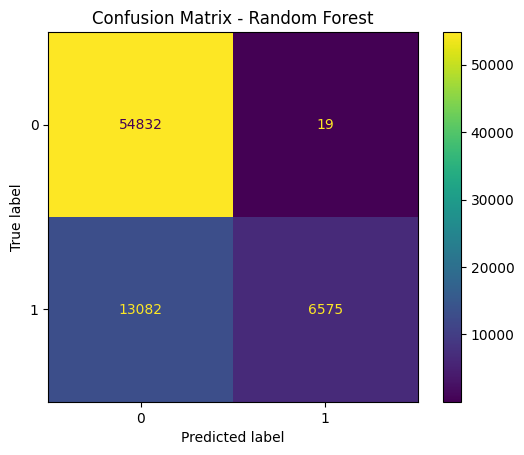

In [25]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

# Initialize SparkSession if not already active
if 'spark' not in locals():
    spark = SparkSession.builder \
        .appName("ChicagoCrimeArrest") \
        .config("spark.sql.shuffle.partitions", "200") \
        .getOrCreate()

# Re-define paths and load data (assuming spark session is active)
gold_path = "/content/drive/MyDrive/chicago/gold_mlready"
df_gold = spark.read.parquet(gold_path)

# Re-split data
train_df, test_df = df_gold.randomSplit([0.8, 0.2], seed=42)

# Re-define feature engineering components
categorical_cols = [
    "Primary Type", "Location Description",
    "District", "Ward", "Community Area", "FBI Code"
]

numeric_cols = ["Latitude", "Longitude", "Hour", "DayOfWeek", "Month", "IsWeekend", "Domestic"]

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in categorical_cols],
    outputCols=[c + "_ohe" for c in categorical_cols]
)

assembler = VectorAssembler(
    inputCols=[c + "_ohe" for c in categorical_cols] + numeric_cols,
    outputCol="features_unnormalized"
)

scaler = StandardScaler(
    inputCol="features_unnormalized",
    outputCol="features",
    withMean=False,
    withStd=True
)

# Re-define the RandomForestClassifier (rf)
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)

# Build the full RandomForest pipeline
base_stages = indexers + [encoder, assembler, scaler]
rf_pipeline = Pipeline(stages=base_stages + [rf])

# Explicitly cast 'Domestic' to IntegerType for train_df and test_df
train_df_prepared = train_df.withColumn("Domestic", col("Domestic").cast("int"))
test_df_prepared = test_df.withColumn("Domestic", col("Domestic").cast("int"))

# Fit model
rf_model = rf_pipeline.fit(train_df_prepared)
pred_rf = rf_model.transform(test_df_prepared)

# Convert predictions to pandas
pred_pd = pred_rf.select("label", "prediction").toPandas()

# Confusion Matrix
cm = confusion_matrix(pred_pd['label'], pred_pd['prediction'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

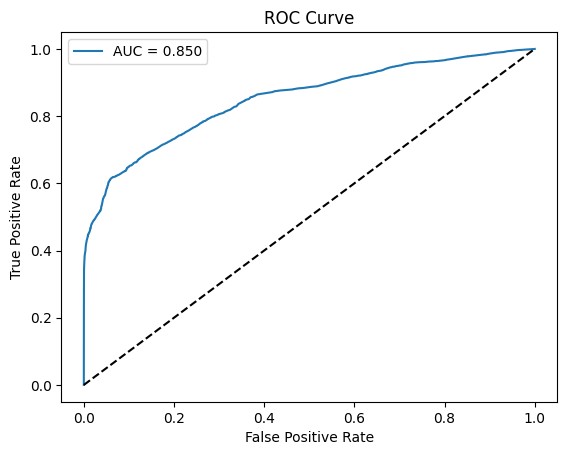

In [26]:
from sklearn.metrics import roc_curve, auc

# Convert to pandas
pdf = pred_rf.select("label", "probability").toPandas()

# Extract probability of class 1 (arrest)
pdf['prob1'] = pdf['probability'].apply(lambda x: float(x[1]))

# Compute ROC values
fpr, tpr, thresholds = roc_curve(pdf['label'], pdf['prob1'])
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

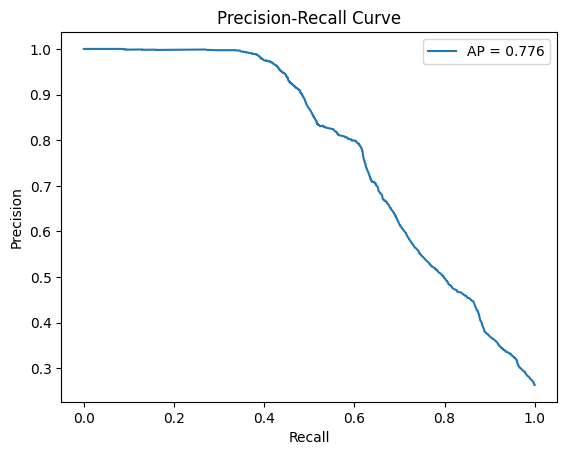

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(pdf['label'], pdf['prob1'])
ap = average_precision_score(pdf['label'], pdf['prob1'])

plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

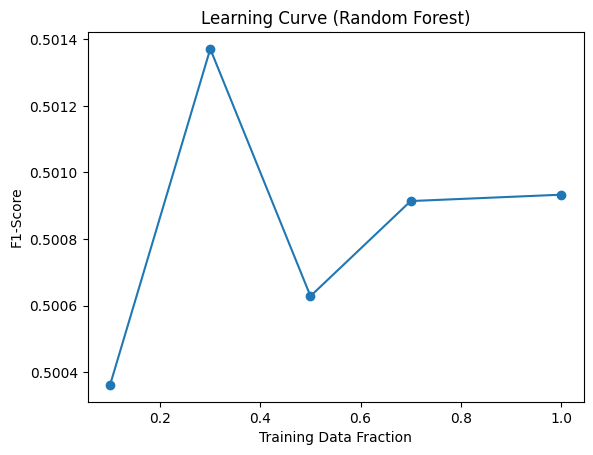

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

train_sizes = [0.1, 0.3, 0.5, 0.7, 1.0]
scores = []

for size in train_sizes:
    # Sample a fraction of training data
    sampled_train_df = train_df_prepared.sample(withReplacement=False, fraction=size, seed=42)

    # Fit the Random Forest pipeline to the sampled training data
    # Use the full pipeline from the 'pipelines' dictionary
    fitted_pipeline_model = pipelines["RandomForest"].fit(sampled_train_df)

    # Predict on test set
    pred = fitted_pipeline_model.transform(test_df_prepared)

    # Evaluate using F1-score
    pdf_results = pred.select("label", "prediction").toPandas()
    f1 = f1_score(pdf_results['label'], pdf_results['prediction'])
    scores.append(f1)

# Plot learning curve
plt.plot(train_sizes, scores, marker='o')
plt.xlabel("Training Data Fraction")
plt.ylabel("F1-Score")
plt.title("Learning Curve (Random Forest)")
plt.show()